Part A
Linear: MSE=7.1151  R2=0.0053
Cubic: MSE=6.8949  R2=0.0361
Better fit: Cubic


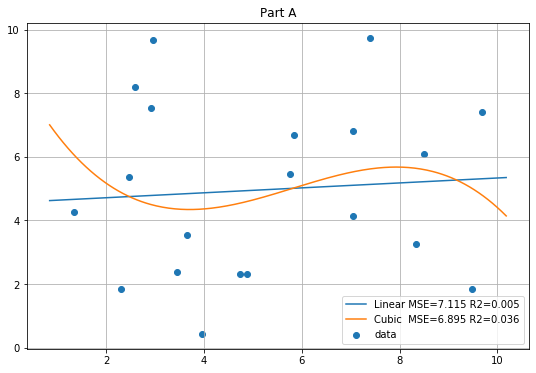


Part B
deg=1  MSE=7.1151  R2=0.0053 (underfit)
deg=2  MSE=7.1004  R2=0.0074
deg=3  MSE=6.8949  R2=0.0361
deg=4  MSE=6.5562  R2=0.0835
deg=5  MSE=4.9539  R2=0.3075
deg=6  MSE=4.5823  R2=0.3594
deg=7  MSE=4.4042  R2=0.3843
deg=8  MSE=2.0908  R2=0.7077
deg=9  MSE=1.4938  R2=0.7912
deg=10  MSE=1.4915  R2=0.7915 (overfit)
deg=11  MSE=1.4904  R2=0.7916 (overfit)
deg=12  MSE=0.9207  R2=0.8713 (overfit)
deg=13  MSE=0.5973  R2=0.9165 (overfit)
deg=14  MSE=0.5899  R2=0.9175 (overfit)
deg=15  MSE=0.4687  R2=0.9345 (overfit)


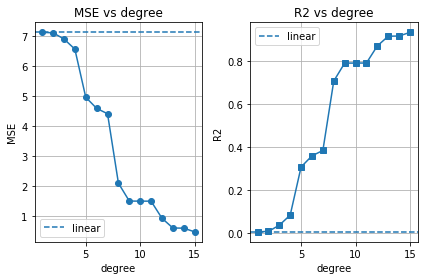

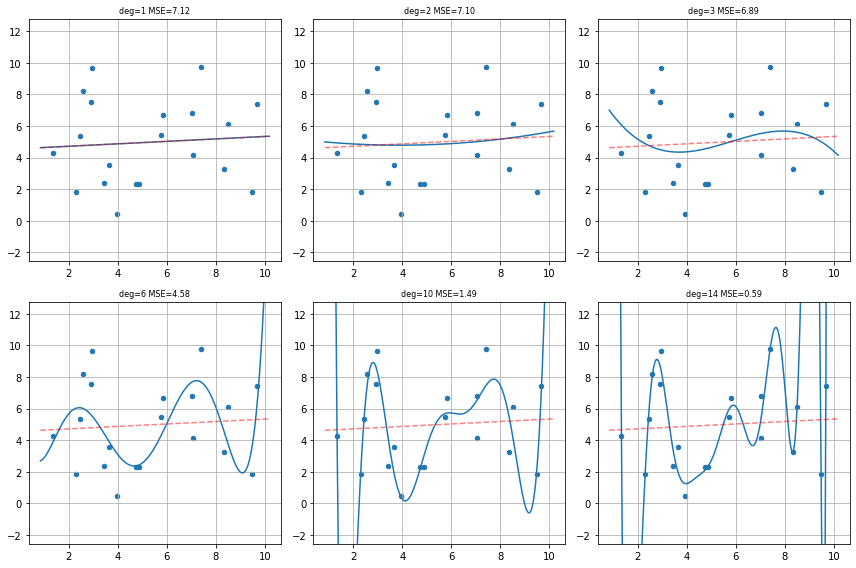


Part C
Vandermonde: MSE=6.8949 R2=0.0361
Polyfit: MSE=6.8949 R2=0.0361  
Vandermonde coeffs: [ 9.21551402 -3.11505301  0.61682295 -0.03533787]
Polyfit coeffs: [ 9.21551402 -3.11505301  0.61682295 -0.03533787]


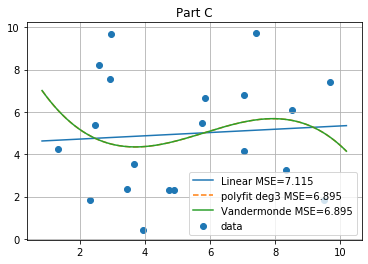

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# generate random data
xData = np.random.uniform(0, 10, 20)
yData = np.random.uniform(0, 10, 20)
xPlot = np.linspace(xData.min() - 0.5, xData.max() + 0.5, 300)

# MSE and R^2
def calcMetrics(yTrue, yPred):
    mse = np.mean((yTrue - yPred) ** 2)
    ssTot = np.sum((yTrue - np.mean(yTrue)) ** 2)
    ssRes = np.sum((yTrue - yPred) ** 2)
    r2 = 1 - ssRes / ssTot
    return mse, r2

# linear least squares
A = np.vstack([xData, np.ones(len(xData))]).T
slope, intercept = np.linalg.lstsq(A, yData, rcond=None)[0]
yLinear = slope * xData + intercept
mseLin, r2Lin = calcMetrics(yData, yLinear)

# Part A
coeffsA = np.polyfit(xData, yData, 3)
polyA = np.poly1d(coeffsA)
mseA, r2A = calcMetrics(yData, polyA(xData))

print("Part A")
print(f"Linear: MSE={mseLin:.4f}  R2={r2Lin:.4f}")
print(f"Cubic: MSE={mseA:.4f}  R2={r2A:.4f}")
print(f"Better fit: {'Cubic' if r2A > r2Lin else 'Linear'}")

plt.figure(figsize=(9, 6))
plt.scatter(xData, yData, label='data')
plt.plot(xPlot, slope * xPlot + intercept, label=f'Linear MSE={mseLin:.3f} R2={r2Lin:.3f}')
plt.plot(xPlot, polyA(xPlot), label=f'Cubic  MSE={mseA:.3f} R2={r2A:.3f}')
plt.title('Part A')
plt.legend()
plt.grid(True)
plt.show()

# Part B
degrees = list(range(1, 16))
mseList = []
r2List = []

for d in degrees:
    p = np.poly1d(np.polyfit(xData, yData, d))
    mse, r2 = calcMetrics(yData, p(xData))
    mseList.append(mse)
    r2List.append(r2)

print("\nPart B")
for d, mse, r2 in zip(degrees, mseList, r2List):
    if d == 1:
        note = " (underfit)"
    elif d >= 10:
        note = " (overfit)"
    else:
        note = ""
    print(f"deg={d}  MSE={mse:.4f}  R2={r2:.4f}{note}")

plt.figure()
plt.subplot(1, 2, 1)
plt.plot(degrees, mseList, 'o-')
plt.axhline(mseLin, linestyle='--', label='linear')
plt.xlabel('degree')
plt.ylabel('MSE')
plt.title('MSE vs degree')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(degrees, r2List, 's-')
plt.axhline(r2Lin, linestyle='--', label='linear')
plt.xlabel('degree')
plt.ylabel('R2')
plt.title('R2 vs degree')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# plots to show what happens as degree increases
sampleDegrees = [1, 2, 3, 6, 10, 14]
plt.figure(figsize=(12, 8))
for i, d in enumerate(sampleDegrees, 1):
    p = np.poly1d(np.polyfit(xData, yData, d))
    mse, r2 = calcMetrics(yData, p(xData))
    plt.subplot(2, 3, i)
    plt.scatter(xData, yData, s=20)
    plt.plot(xPlot, p(xPlot))
    plt.plot(xPlot, slope * xPlot + intercept, 'r--', alpha=0.5)
    plt.title(f'deg={d} MSE={mse:.2f}', fontsize=8)
    plt.ylim(yData.min() - 3, yData.max() + 3)
    plt.grid(True)
plt.tight_layout()
plt.show()

# Part C
def vandermondeFit(x, y, deg):
    V = np.vander(x, N=deg + 1, increasing=True)
    coeffs = np.linalg.solve(V.T @ V, V.T @ y)
    return coeffs, V

coeffsC, VC = vandermondeFit(xData, yData, 3)
mseC, r2C = calcMetrics(yData, VC @ coeffsC)

yVanPlot = np.vander(xPlot, N=4, increasing=True) @ coeffsC

print("\nPart C")
print(f"Vandermonde: MSE={mseC:.4f} R2={r2C:.4f}")
print(f"Polyfit: MSE={mseA:.4f} R2={r2A:.4f}  ")
print(f"Vandermonde coeffs: {coeffsC}")
print(f"Polyfit coeffs: {np.polyfit(xData, yData, 3)[::-1]}")

plt.figure()
plt.scatter(xData, yData, label='data')
plt.plot(xPlot, slope * xPlot + intercept, label=f'Linear MSE={mseLin:.3f}')
plt.plot(xPlot, polyA(xPlot), '--', label=f'polyfit deg3 MSE={mseA:.3f}')
plt.plot(xPlot, yVanPlot, label=f'Vandermonde MSE={mseC:.3f}')
plt.title('Part C')
plt.legend()
plt.grid(True)
plt.show()